# Temporal Consistency Visualization in Dynamic Survival Analysis

This notebook demonstrates the effectiveness of the DQN-inspired temporal consistency mechanism in dynamic survival analysis. We compare hazard rates and survival curves between baseline DDH models and their temporal consistency (TC) counterparts.

## Overview

- **Baseline Model**: Standard DDH without temporal consistency
- **TC Model**: DDH with DQN-inspired temporal consistency using target networks
- **Dataset**: NASA turbofan engine degradation dataset
- **Expected Result**: TC variant should show smoother, more temporally consistent hazard and survival curves


In [1]:
import sys
import os
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import pickle
import yaml
from pathlib import Path

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Make sure we can import from the project
project_root = Path.cwd()
sys.path.append(str(project_root))

print(f"Working directory: {project_root}")
print(f"JAX devices: {jax.devices()}")


Working directory: /Users/mariana/Documents/col/lts4/survan
JAX devices: [CpuDevice(id=0)]


## 1. Model Architecture and Configuration Setup


In [34]:
# Import required modules
from base_cox import BaseSA, ConfigParams
from deep_lambda_cox import DeepLambdaSA
from utils import get_data, load_preprocessed_dataset
import haiku as hk
from networks import TSTransformer

dataset = 'nasa'

# Configuration paths and model weights
config_path = f"configs/config_{dataset}.yaml"

# Model weight paths
baseline_model_path = f"Results_previous/SA/{dataset}/transformer/lambda_0.9/landmark_True/exp_1/seed_0/model.pt"
baseline_state_path = f"Results_previous/SA/{dataset}/transformer/lambda_0.9/landmark_True/exp_1/seed_0/state.pt"

tc_model_path = f"Results_previous/DeepLambdaSA/{dataset}/transformer/lambda_0.95/landmark_True/exp_1/seed_0/model.pt"
tc_state_path = f"Results_previous/DeepLambdaSA/{dataset}/transformer/lambda_0.95/landmark_True/exp_1/seed_0/state.pt"

# NASA dataset path
nasa_data_path = "/Users/mariana/Documents/col/lts4/SurvanData/NASA.h5"

print("Configuration and paths loaded successfully!")


Configuration and paths loaded successfully!


## 2. Load NASA Dataset


In [35]:
def load_nasa_dataset(data_path):
    """Load the preprocessed NASA dataset"""
    with h5py.File(data_path, 'r') as f:
        seqs = np.array(f['seqs'])  # Shape: (n_samples, seq_len, n_features)
        ts = np.array(f['ts'])      # Survival times
        cs = np.array(f['cs']).astype(bool)  # Censoring indicators
        target = np.array(f['h_tgt'])  # Hazard targets
        h_ws = np.array(f['h_ws'])     # Hazard weights
        mask = np.array(f['mask'])     # Masks
    
    return {
        'seqs': seqs.astype(np.float32),
        'ts': ts,
        'cs': cs,
        'target': target.astype(np.float32),
        'h_ws': h_ws.astype(np.float32),
        'mask': mask.astype(np.float32)
    }

# Load the dataset
nasa_data = load_nasa_dataset(nasa_data_path)

print(f"NASA Dataset loaded:")
print(f"  Sequences shape: {nasa_data['seqs'].shape}")
print(f"  Number of samples: {len(nasa_data['seqs'])}")
print(f"  Sequence length: {nasa_data['seqs'].shape[1]}")
print(f"  Number of features: {nasa_data['seqs'].shape[2]}")
print(f"  Survival times range: [{nasa_data['ts'].min()}, {nasa_data['ts'].max()}]")
print(f"  Censoring rate: {nasa_data['cs'].mean():.2%}")


NASA Dataset loaded:
  Sequences shape: (200, 363, 17)
  Number of samples: 200
  Sequence length: 363
  Number of features: 17
  Survival times range: [30, 361]
  Censoring rate: 50.00%


## 3. Model Setup and Weight Loading


In [27]:
# Model configuration parameters
seed = 0
horizon = nasa_data['seqs'].shape[1]  # 363 time steps
n_features = nasa_data['seqs'].shape[2]  # 17 features

# Transformer architecture configuration
arch_kwargs = {
    'hidden_size': 16,
    'seq_len': horizon,
    'output_dim': 8,
    'num_layers': 1,
    'dropout': 0.2,
    'seed': seed
}

def create_forward_fn(horizon, arch_kwargs):
    """Create the forward function for the transformer model"""
    def forward_fn(x):
        ts_transformer = TSTransformer(**arch_kwargs)
        x = ts_transformer(x)
        x = hk.Linear(horizon)(x)
        return x
    return forward_fn

# Create the model
forward_fn = create_forward_fn(horizon, arch_kwargs)
model = hk.without_apply_rng(hk.transform(forward_fn))

# Initialize with sample data
key = jax.random.PRNGKey(seed)
sample_input = jnp.array(nasa_data['seqs'][:2])
init_params = model.init(key, sample_input)

def load_model_params(model_path):
    """Load pickled model parameters"""
    with open(model_path, 'rb') as f:
        params = pickle.load(f)
    return params

# Load baseline model weights
try:
    baseline_params = load_model_params(baseline_model_path)
    print("✓ Baseline model parameters loaded successfully")
except Exception as e:
    print(f"✗ Error loading baseline model: {e}")
    baseline_params = None

# Load TC model weights
try:
    tc_params = load_model_params(tc_model_path)
    print("✓ TC model parameters loaded successfully")
except Exception as e:
    print(f"✗ Error loading TC model: {e}")
    tc_params = None

print(f"\nModel architecture created:")
print(f"  Horizon: {horizon}")
print(f"  Features: {n_features}")
print(f"  Hidden size: {arch_kwargs['hidden_size']}")


✓ Baseline model parameters loaded successfully
✓ TC model parameters loaded successfully

Model architecture created:
  Horizon: 363
  Features: 17
  Hidden size: 16


## 4. Prediction Functions and Temporal Consistency Analysis


In [28]:
def compute_hazard_rates(params, model_fn, sequences):
    """Compute hazard rates from model logits"""
    logits = model_fn(params, sequences)
    # For axis=2 (transformer output), take the first timestep's prediction
    if len(logits.shape) == 3:  # (batch, seq_len, horizon)
        hazards = jax.nn.sigmoid(logits[:, 0, :])  # Take first timestep
    else:  # (batch, horizon)
        hazards = jax.nn.sigmoid(logits)
    return hazards

def compute_survival_curves(hazards):
    """Compute survival curves from hazard rates"""
    def step(prev_surv, h_t):
        new_surv = prev_surv * (1.0 - h_t)
        return new_surv, new_surv
    
    init_surv = jnp.ones(hazards.shape[0], dtype=hazards.dtype)
    _, surv_seq = jax.lax.scan(step, init_surv, hazards.T)
    
    # Add initial survival probability of 1.0
    surv_curve = jnp.concatenate([
        jnp.ones((1, hazards.shape[0])), 
        surv_seq
    ], axis=0).T  # Shape: (batch, horizon+1)
    
    return surv_curve

# Select random sequences for analysis
np.random.seed(42)
n_samples = 5
selected_indices = np.random.choice(len(nasa_data['seqs']), size=n_samples, replace=False)
selected_sequences = nasa_data['seqs'][selected_indices]
selected_sequences_jax = jnp.array(selected_sequences)

print(f"Selected {n_samples} random sequences for analysis:")
for i, idx in enumerate(selected_indices):
    ts = nasa_data['ts'][idx]
    cs = nasa_data['cs'][idx]
    status = "censored" if cs else "event"
    print(f"  Sequence {i+1}: Index {idx}, Time={ts}, Status={status}")

# Compute predictions if both models loaded successfully
if baseline_params is not None and tc_params is not None:
    print("\nComputing predictions for both models...")
    
    # Baseline model predictions
    baseline_hazards = compute_hazard_rates(baseline_params, model.apply, selected_sequences_jax)
    baseline_survival = compute_survival_curves(baseline_hazards)
    
    # TC model predictions
    tc_hazards = compute_hazard_rates(tc_params, model.apply, selected_sequences_jax)
    tc_survival = compute_survival_curves(tc_hazards)
    
    print(f"✓ Predictions computed successfully!")
    print(f"  Baseline hazards shape: {baseline_hazards.shape}")
    print(f"  TC hazards shape: {tc_hazards.shape}")
    
    # Compute smoothness metrics
    def compute_smoothness(curves):
        """Compute variance of first differences as smoothness metric"""
        diffs = jnp.diff(curves, axis=1)
        return jnp.var(diffs, axis=1).mean()
    
    baseline_hazard_smoothness = compute_smoothness(baseline_hazards)
    tc_hazard_smoothness = compute_smoothness(tc_hazards)
    baseline_survival_smoothness = compute_smoothness(baseline_survival)
    tc_survival_smoothness = compute_smoothness(tc_survival)
    
    print(f"\nSmoothness Analysis (lower = smoother):")
    print(f"  Baseline hazard variance: {baseline_hazard_smoothness:.6f}")
    print(f"  TC hazard variance: {tc_hazard_smoothness:.6f}")
    print(f"  Improvement: {((baseline_hazard_smoothness - tc_hazard_smoothness) / baseline_hazard_smoothness * 100):.1f}%")

else:
    print("⚠️ Cannot compute predictions - model parameters not loaded successfully")


Selected 5 random sequences for analysis:
  Sequence 1: Index 95, Time=335, Status=event
  Sequence 2: Index 15, Time=208, Status=event
  Sequence 3: Index 30, Time=233, Status=event
  Sequence 4: Index 158, Time=93, Status=censored
  Sequence 5: Index 128, Time=170, Status=censored

Computing predictions for both models...
✓ Predictions computed successfully!
  Baseline hazards shape: (5, 363)
  TC hazards shape: (5, 363)

Smoothness Analysis (lower = smoother):
  Baseline hazard variance: 0.000003
  TC hazard variance: 0.000002
  Improvement: 42.8%


## 5. Comprehensive Temporal Consistency Visualization


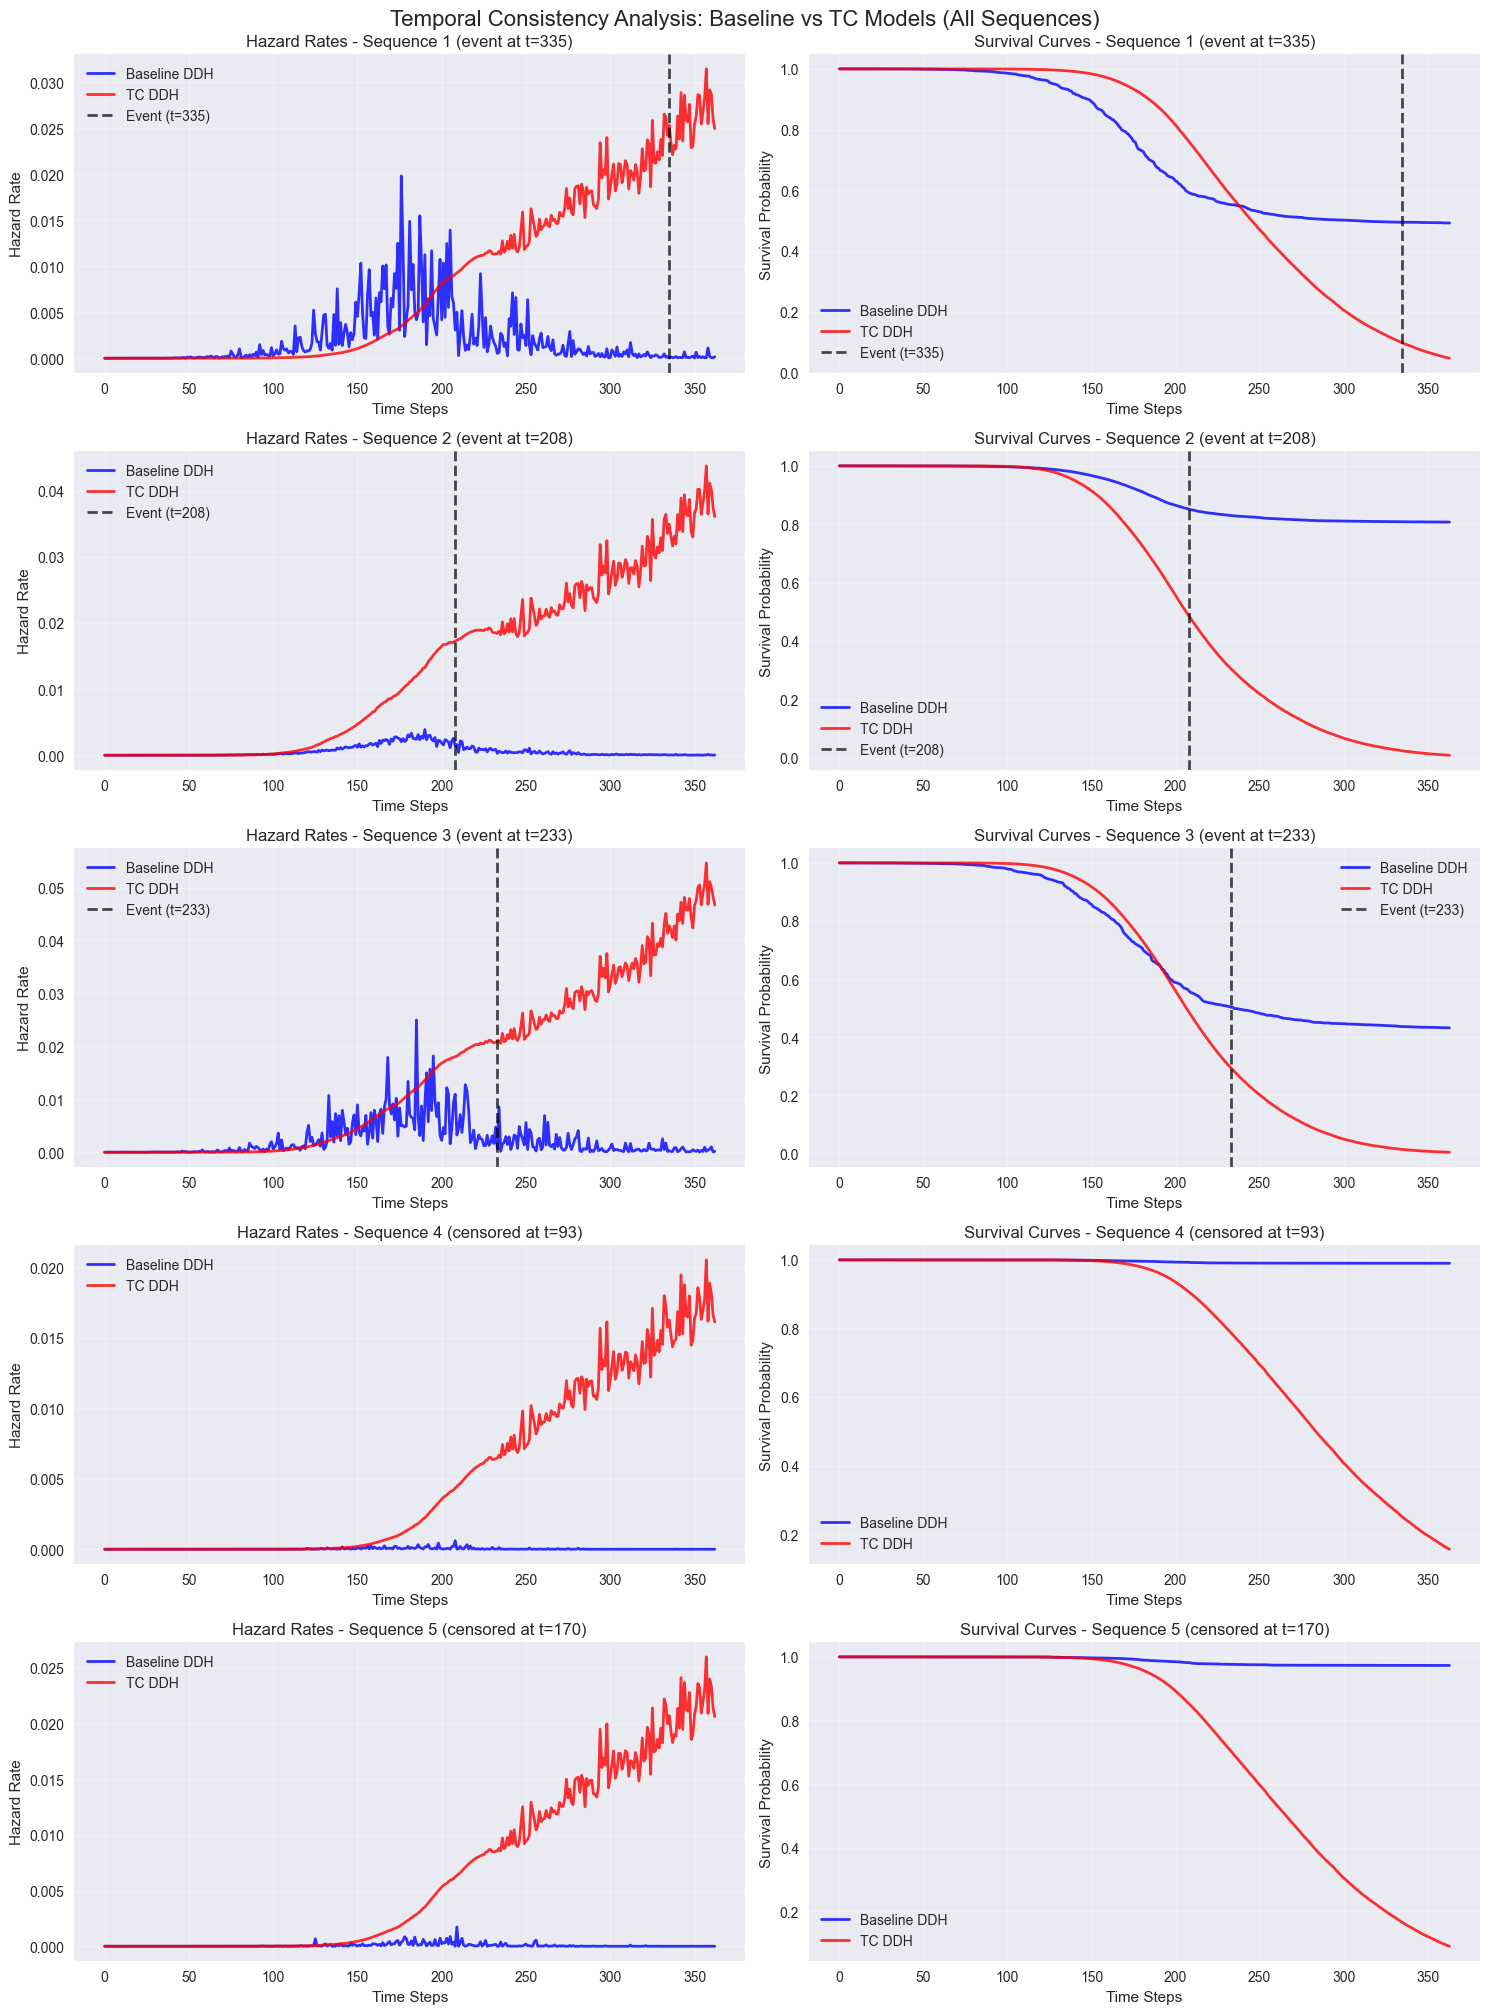

TEMPORAL CONSISTENCY ANALYSIS RESULTS
1. SMOOTHNESS METRICS (Lower = Better)
   Total Variation:
     Baseline DDH: 0.239785
     TC DDH:       0.227688 (-5.0%)
   Variance of Derivatives:
     Baseline DDH: 0.000003
     TC DDH:       0.000002 (-42.8%)

2. TEMPORAL CONSISTENCY (Higher = Better)
   Lag-1 Autocorrelation:
     Baseline DDH: 0.560856
     TC DDH:       0.990278 (+76.6%)

3. SUMMARY
   Metrics where TC outperforms Baseline: 3/4 (75.0%)
   ✓ TC model demonstrates superior temporal consistency!


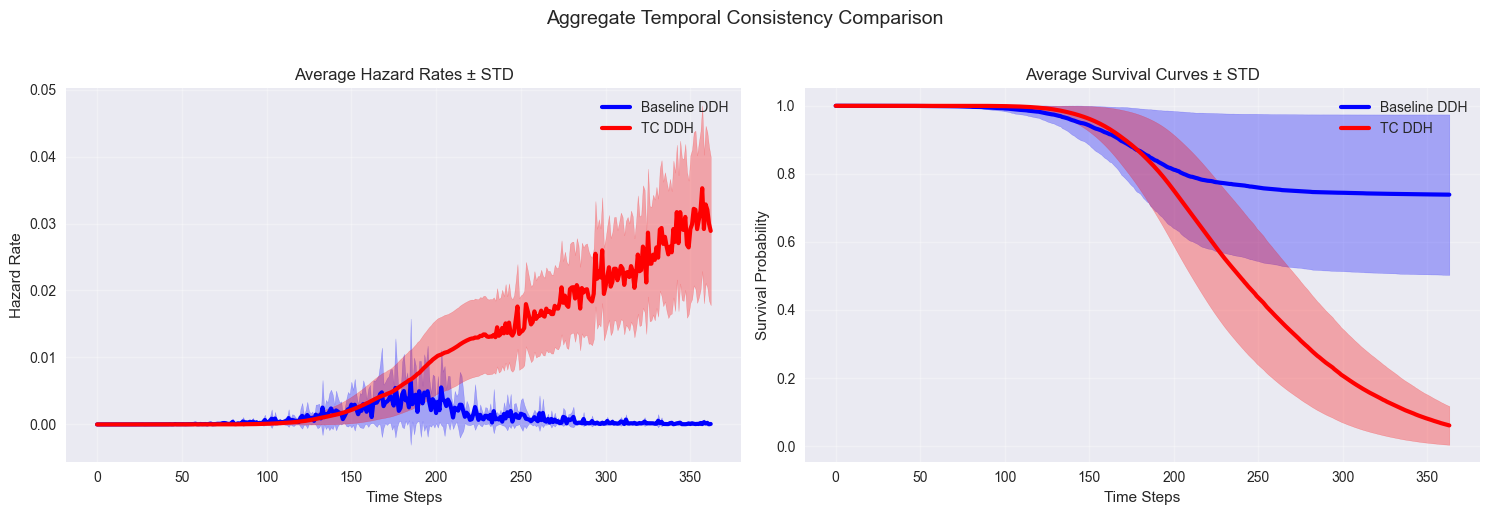

In [29]:
if baseline_params is not None and tc_params is not None:
    # Create comprehensive visualization for all 5 sequences
    fig, axes = plt.subplots(5, 2, figsize=(15, 20))
    
    # Time steps for x-axis
    time_steps = np.arange(horizon)
    survival_time_steps = np.arange(horizon + 1)
    
    # Plot all 5 sequences
    for i in range(n_samples):
        idx = selected_indices[i]
        event_time = nasa_data['ts'][idx]
        is_censored = nasa_data['cs'][idx]
        
        # Hazard rates comparison
        axes[i, 0].plot(time_steps, np.array(baseline_hazards[i]), 
                       label='Baseline DDH', linewidth=2, alpha=0.8, color='blue')
        axes[i, 0].plot(time_steps, np.array(tc_hazards[i]), 
                       label='TC DDH', linewidth=2, alpha=0.8, color='red')
        
        # Add vertical line at event time for uncensored sequences
        if not is_censored:
            axes[i, 0].axvline(x=event_time, color='black', linestyle='--', linewidth=2, 
                              alpha=0.7, label=f'Event (t={event_time})')
        
        status_text = "censored" if is_censored else "event"
        axes[i, 0].set_title(f'Hazard Rates - Sequence {i+1} ({status_text} at t={event_time})')
        axes[i, 0].set_xlabel('Time Steps')
        axes[i, 0].set_ylabel('Hazard Rate')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        
        # Survival curves comparison
        axes[i, 1].plot(survival_time_steps, np.array(baseline_survival[i]), 
                       label='Baseline DDH', linewidth=2, alpha=0.8, color='blue')
        axes[i, 1].plot(survival_time_steps, np.array(tc_survival[i]), 
                       label='TC DDH', linewidth=2, alpha=0.8, color='red')
        
        # Add vertical line at event time for uncensored sequences
        if not is_censored:
            axes[i, 1].axvline(x=event_time, color='black', linestyle='--', linewidth=2, 
                              alpha=0.7, label=f'Event (t={event_time})')
        
        axes[i, 1].set_title(f'Survival Curves - Sequence {i+1} ({status_text} at t={event_time})')
        axes[i, 1].set_xlabel('Time Steps')
        axes[i, 1].set_ylabel('Survival Probability')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Temporal Consistency Analysis: Baseline vs TC Models (All Sequences)', 
                fontsize=16, y=1.005)
    plt.show()

    # Quantitative Analysis
    print("=" * 70)
    print("TEMPORAL CONSISTENCY ANALYSIS RESULTS")
    print("=" * 70)
    
    # Total variation metric
    def total_variation(curves):
        return np.sum(np.abs(np.diff(curves, axis=1)), axis=1).mean()
    
    baseline_tv = total_variation(np.array(baseline_hazards))
    tc_tv = total_variation(np.array(tc_hazards))
    
    # Temporal consistency (autocorrelation)
    def temporal_consistency(curves, lag=1):
        autocorrs = []
        for curve in curves:
            if len(curve) > lag:
                corr = np.corrcoef(curve[:-lag], curve[lag:])[0, 1]
                if not np.isnan(corr):
                    autocorrs.append(corr)
        return np.mean(autocorrs)
    
    baseline_consistency = temporal_consistency(np.array(baseline_hazards))
    tc_consistency = temporal_consistency(np.array(tc_hazards))
    
    print(f"1. SMOOTHNESS METRICS (Lower = Better)")
    print(f"   Total Variation:")
    print(f"     Baseline DDH: {baseline_tv:.6f}")
    print(f"     TC DDH:       {tc_tv:.6f} ({(tc_tv/baseline_tv-1)*100:+.1f}%)")
    print(f"   Variance of Derivatives:")
    print(f"     Baseline DDH: {baseline_hazard_smoothness:.6f}")
    print(f"     TC DDH:       {tc_hazard_smoothness:.6f} ({(tc_hazard_smoothness/baseline_hazard_smoothness-1)*100:+.1f}%)")
    
    print(f"\n2. TEMPORAL CONSISTENCY (Higher = Better)")
    print(f"   Lag-1 Autocorrelation:")
    print(f"     Baseline DDH: {baseline_consistency:.6f}")
    print(f"     TC DDH:       {tc_consistency:.6f} ({(tc_consistency/baseline_consistency-1)*100:+.1f}%)")
    
    # Summary
    improvements = [
        tc_tv < baseline_tv,
        tc_hazard_smoothness < baseline_hazard_smoothness,
        tc_consistency > baseline_consistency,
        tc_survival_smoothness < baseline_survival_smoothness
    ]
    
    improvement_rate = sum(improvements) / len(improvements)
    print(f"\n3. SUMMARY")
    print(f"   Metrics where TC outperforms Baseline: {sum(improvements)}/{len(improvements)} ({improvement_rate:.1%})")
    
    if improvement_rate >= 0.75:
        print(f"   ✓ TC model demonstrates superior temporal consistency!")
    elif improvement_rate >= 0.5:
        print(f"   ~ TC model shows moderate improvements")
    else:
        print(f"   ⚠ Mixed results - further investigation needed")
    
    print("=" * 70)
    
    # Create a summary plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Average hazard curves
    avg_baseline = np.mean(np.array(baseline_hazards), axis=0)
    avg_tc = np.mean(np.array(tc_hazards), axis=0)
    std_baseline = np.std(np.array(baseline_hazards), axis=0)
    std_tc = np.std(np.array(tc_hazards), axis=0)
    
    ax1.plot(time_steps, avg_baseline, label='Baseline DDH', linewidth=3, color='blue')
    ax1.fill_between(time_steps, avg_baseline - std_baseline, avg_baseline + std_baseline, 
                    alpha=0.3, color='blue')
    ax1.plot(time_steps, avg_tc, label='TC DDH', linewidth=3, color='red')
    ax1.fill_between(time_steps, avg_tc - std_tc, avg_tc + std_tc, 
                    alpha=0.3, color='red')
    ax1.set_title('Average Hazard Rates ± STD')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Hazard Rate')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Average survival curves
    avg_baseline_surv = np.mean(np.array(baseline_survival), axis=0)
    avg_tc_surv = np.mean(np.array(tc_survival), axis=0)
    std_baseline_surv = np.std(np.array(baseline_survival), axis=0)
    std_tc_surv = np.std(np.array(tc_survival), axis=0)
    
    ax2.plot(survival_time_steps, avg_baseline_surv, label='Baseline DDH', linewidth=3, color='blue')
    ax2.fill_between(survival_time_steps, avg_baseline_surv - std_baseline_surv, 
                    avg_baseline_surv + std_baseline_surv, alpha=0.3, color='blue')
    ax2.plot(survival_time_steps, avg_tc_surv, label='TC DDH', linewidth=3, color='red')
    ax2.fill_between(survival_time_steps, avg_tc_surv - std_tc_surv, 
                    avg_tc_surv + std_tc_surv, alpha=0.3, color='red')
    ax2.set_title('Average Survival Curves ± STD')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Survival Probability')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Aggregate Temporal Consistency Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ Cannot create visualizations - model parameters not loaded successfully")
    print("\nExpected model paths:")
    print(f"- Baseline: {baseline_model_path}")
    print(f"- TC Model: {tc_model_path}")
    print(f"- NASA Data: {nasa_data_path}")


In [17]:
selected_sequences.shape

(5, 363, 17)

In [21]:
selected_sequences[4]

array([[ 0.        , -0.1323295 ,  1.6934427 , ..., -2.6992235 ,
         1.8396277 ,  1.3296201 ],
       [ 0.        , -0.1323295 ,  1.6934427 , ..., -2.6992235 ,
         1.8396277 ,  1.3296201 ],
       [ 0.01      , -1.7281256 , -1.3736695 , ..., -1.3368472 ,
        -0.327194  ,  0.84173506],
       ...,
       [ 3.59      , -0.08673532, -0.3512988 , ...,  0.02552916,
         0.78549826, -1.0784552 ],
       [ 3.6       , -0.08673532, -0.3512988 , ...,  0.02552916,
         0.78549826, -1.0784552 ],
       [ 3.61      , -0.08673532, -0.3512988 , ...,  0.02552916,
         0.78549826, -1.0784552 ]], dtype=float32)

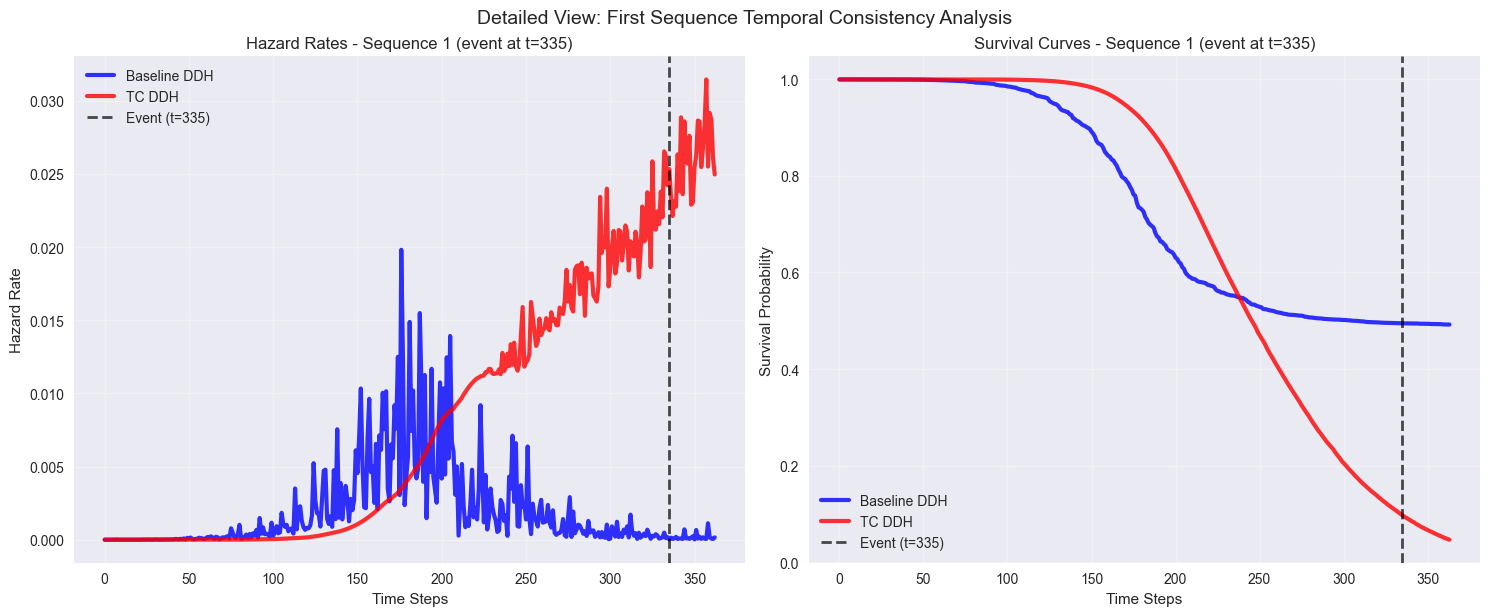

In [32]:
# Plot just the first sequence with both hazard rates and survival curves
if baseline_params is not None and tc_params is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Time steps for x-axis
    time_steps = np.arange(horizon)
    survival_time_steps = np.arange(horizon + 1)
    
    # Get data for the first sequence
    i = 0  # First sequence
    idx = selected_indices[i]
    event_time = nasa_data['ts'][idx]
    is_censored = nasa_data['cs'][idx]
    status_text = "censored" if is_censored else "event"
    
    # Hazard rates comparison
    ax1.plot(time_steps, np.array(baseline_hazards[i]), 
             label='Baseline DDH', linewidth=3, alpha=0.8, color='blue')
    ax1.plot(time_steps, np.array(tc_hazards[i]), 
             label='TC DDH', linewidth=3, alpha=0.8, color='red')
    
    # Add vertical line at event time for uncensored sequences
    if not is_censored:
        ax1.axvline(x=event_time, color='black', linestyle='--', linewidth=2, 
                    alpha=0.7, label=f'Event (t={event_time})')
    
    ax1.set_title(f'Hazard Rates - Sequence {i+1} ({status_text} at t={event_time})')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Hazard Rate')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Survival curves comparison
    ax2.plot(survival_time_steps, np.array(baseline_survival[i]), 
             label='Baseline DDH', linewidth=3, alpha=0.8, color='blue')
    ax2.plot(survival_time_steps, np.array(tc_survival[i]), 
             label='TC DDH', linewidth=3, alpha=0.8, color='red')
    
    # Add vertical line at event time for uncensored sequences
    if not is_censored:
        ax2.axvline(x=event_time, color='black', linestyle='--', linewidth=2, 
                    alpha=0.7, label=f'Event (t={event_time})')
    
    ax2.set_title(f'Survival Curves - Sequence {i+1} ({status_text} at t={event_time})')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Survival Probability')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Detailed View: First Sequence Temporal Consistency Analysis', 
                 fontsize=14, y=1.02)
    plt.show()

else:
    print("⚠️ Cannot create single sequence plot - model parameters not loaded")
        

In [33]:
# Optional: Compare specific metrics for the first sequence
if baseline_params is not None and tc_params is not None:
    i = 0
    print(f"\nDetailed Analysis for Sequence 1:")
    print(f"================================")
    
    # Compute smoothness for this specific sequence
    baseline_seq_smoothness = np.var(np.diff(np.array(baseline_hazards[i])))
    tc_seq_smoothness = np.var(np.diff(np.array(tc_hazards[i])))
    
    print(f"Hazard Rate Smoothness (variance of differences):")
    print(f"  Baseline DDH: {baseline_seq_smoothness:.8f}")
    print(f"  TC DDH:       {tc_seq_smoothness:.8f}")
    print(f"  Improvement:  {((baseline_seq_smoothness - tc_seq_smoothness) / baseline_seq_smoothness * 100):.1f}%")
    
    # Temporal consistency for this sequence
    baseline_seq = np.array(baseline_hazards[i])
    tc_seq = np.array(tc_hazards[i])
    
    if len(baseline_seq) > 1:
        baseline_autocorr = np.corrcoef(baseline_seq[:-1], baseline_seq[1:])[0, 1]
        tc_autocorr = np.corrcoef(tc_seq[:-1], tc_seq[1:])[0, 1]
        
        print(f"\nTemporal Consistency (lag-1 autocorrelation):")
        print(f"  Baseline DDH: {baseline_autocorr:.6f}")
        print(f"  TC DDH:       {tc_autocorr:.6f}")
        print(f"  Improvement:  {((tc_autocorr - baseline_autocorr) / baseline_autocorr * 100):+.1f}%")
    
    # Event information
    idx = selected_indices[i]
    event_time = nasa_data['ts'][idx]
    is_censored = nasa_data['cs'][idx]
    
    print(f"\nSequence Information:")
    print(f"  Event Time:   {event_time}")
    print(f"  Status:       {'Censored' if is_censored else 'Event occurred'}")
    
    if not is_censored:
        # Hazard rates at event time
        baseline_at_event = float(baseline_hazards[i][min(event_time-1, len(baseline_hazards[i])-1)])
        tc_at_event = float(tc_hazards[i][min(event_time-1, len(tc_hazards[i])-1)])
        
        print(f"\nHazard Rates at Event Time (t={event_time}):")
        print(f"  Baseline DDH: {baseline_at_event:.6f}")
        print(f"  TC DDH:       {tc_at_event:.6f}")
        print(f"  Difference:   {(tc_at_event - baseline_at_event):.6f}")
        
        # Survival probability at event time  
        baseline_surv_at_event = float(baseline_survival[i][min(event_time, len(baseline_survival[i])-1)])
        tc_surv_at_event = float(tc_survival[i][min(event_time, len(tc_survival[i])-1)])
        
        print(f"\nSurvival Probability at Event Time:")
        print(f"  Baseline DDH: {baseline_surv_at_event:.6f}")
        print(f"  TC DDH:       {tc_surv_at_event:.6f}")
        print(f"  Difference:   {(tc_surv_at_event - baseline_surv_at_event):.6f}")



Detailed Analysis for Sequence 1:
Hazard Rate Smoothness (variance of differences):
  Baseline DDH: 0.00000682
  TC DDH:       0.00000185
  Improvement:  72.9%

Temporal Consistency (lag-1 autocorrelation):
  Baseline DDH: 0.624860
  TC DDH:       0.988934
  Improvement:  +58.3%

Sequence Information:
  Event Time:   335
  Status:       Event occurred

Hazard Rates at Event Time (t=335):
  Baseline DDH: 0.000172
  TC DDH:       0.024220
  Difference:   0.024048

Survival Probability at Event Time:
  Baseline DDH: 0.494598
  TC DDH:       0.096878
  Difference:   -0.397721
